## Load the data

In [2]:
import numpy as np
from collections import Counter

X = np.load("../Data/X.npy")
y = np.load("../Data/y.npy")

print(X.shape)
print(Counter(y))

(101163, 250)
Counter({np.int64(0): 90347, np.int64(2): 7235, np.int64(1): 2779, np.int64(3): 802})


## Computing the class weigths

In [7]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.2799290513243384), np.int64(1): np.float64(9.100665707088881), np.int64(2): np.float64(3.495611610228058), np.int64(3): np.float64(31.534600997506235)}


## Visualizing the ECG signals

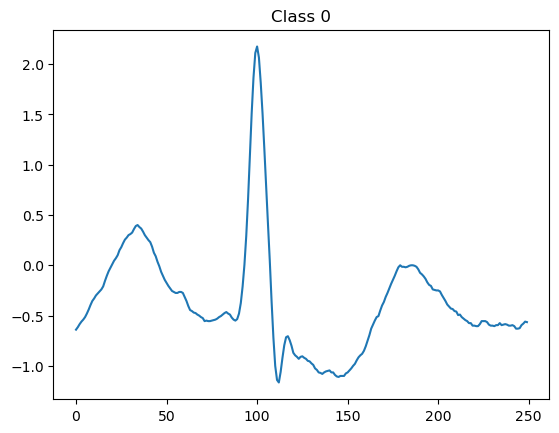

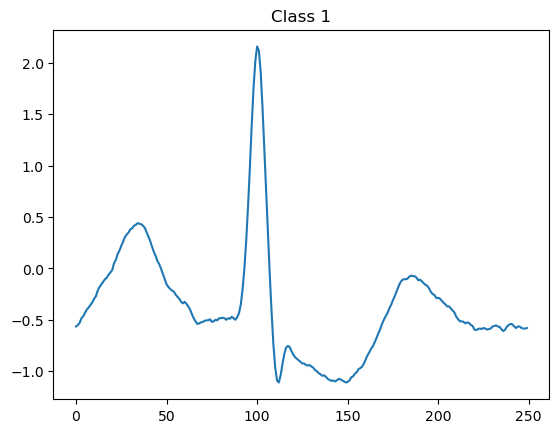

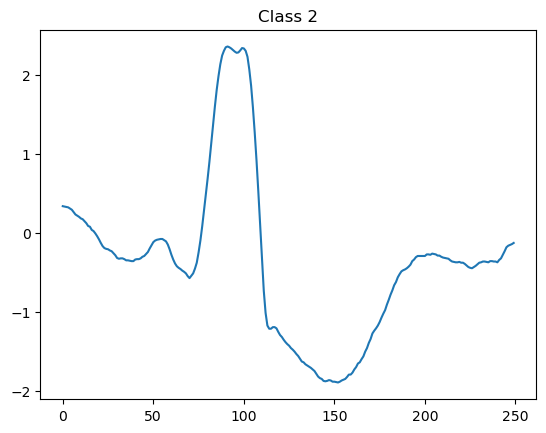

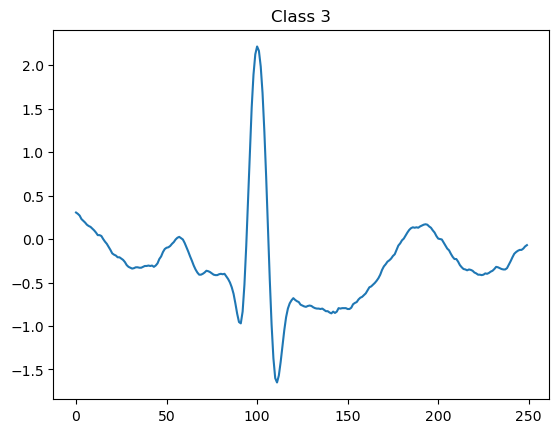

In [3]:
import matplotlib.pyplot as plt

for cls in [0,1,2,3]:
    idx = np.where(y == cls)[0][0]
    plt.plot(X[idx])
    plt.title(f"Class {cls}")
    plt.show()

## Class distributions

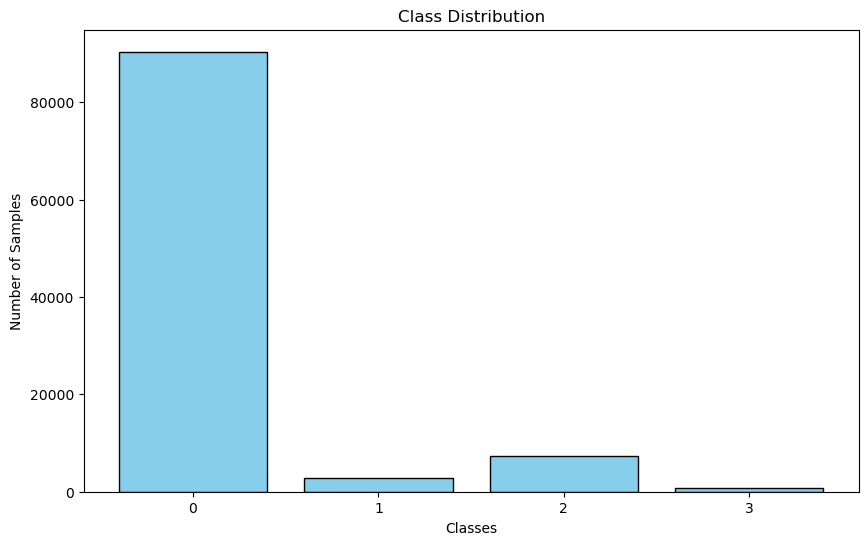

In [8]:
counts = Counter(y)
labels, values = zip(*counts.items())

plt.figure(figsize=(10, 6))
plt.bar(labels, values, color='skyblue', edgecolor='black')

plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.xticks(labels) # Ensures every class label is shown

plt.show()

* Class 0 = Normal beats
* Class 1 = Supraventricular (Atrial), premature beats
* Class 2 = Ventricular, generally more "dangerous" than Class 1
* Class 3 = Fusion of ventricular and normal beats

## Inspecting "Average" Beats vs. Noisy Beats

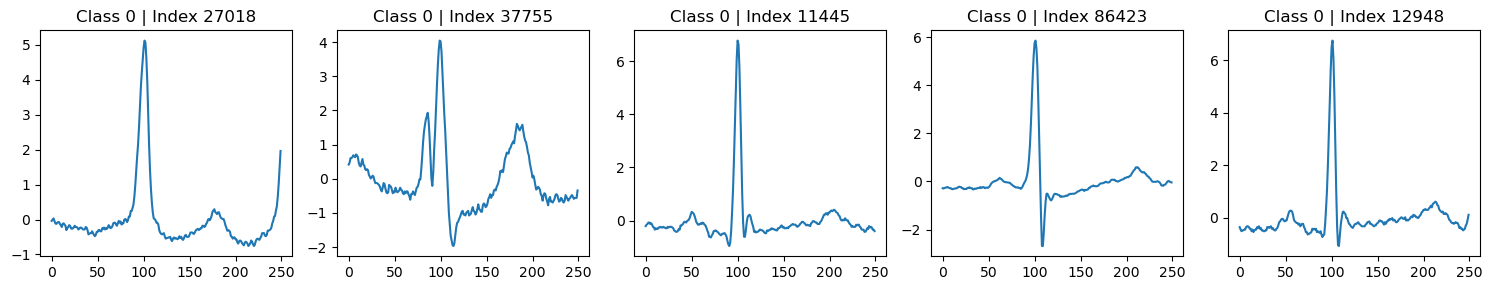

In [14]:
def plot_beat_grid(X, y, class_id, num_samples=5):
    # Get indices for the specific class
    indices = np.where(y == class_id)[0]
    selected = np.random.choice(indices, num_samples, replace=False)
    
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(selected):
        plt.subplot(1, num_samples, i+1)
        plt.plot(X[idx])
        plt.title(f"Class {class_id} | Index {idx}")
    plt.tight_layout()
    plt.show()

# Inspect 5 random 'Normal' beats to look for noise
plot_beat_grid(X, y, class_id=0)

## Normalize the data

In [4]:
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

## Train and Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Convert to PyTorch

In [6]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.long)